In [ ]:
### Data analysis
import numpy as np
import pandas as pd

#### Visualisation
import matplotlib.pyplot as plt

### StandardScalar
from sklearn.preprocessing import StandardScaler
### KNN
from sklearn.neighbors import KNeighborsClassifier
### Performance metric
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, classification_report


In [ ]:
### Load the data
df_train = pd.read_csv("/content/train_KNN.csv")
df_test = pd.read_csv("/content/test_KNN.csv")

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [ ]:
df_train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
mp = 100*(df_train.isnull().sum()/len(df_train))
mp

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


In [ ]:
mp = mp[mp>0].sort_values()

In [ ]:
mp

,0
Embarked,0.224467
Age,19.865320
Cabin,77.104377


In [ ]:
df_train["Age"].median()

28.0

In [ ]:
df_train["Fare"].median()

14.4542

In [ ]:
df_train[df_train["Embarked"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


In [ ]:
df_train = df_train.dropna(axis = 0, subset= ["Embarked"])

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          712 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Cabin        202 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 90.3+ KB


In [ ]:
df_train["Age"] = df_train["Age"].fillna(df_train["Age"].median())

In [ ]:
df_train = df_train.drop(["Cabin"], axis = 1)  ## 1 is for column

In [ ]:
####Testing

In [ ]:
mpt = 100*(df_test.isnull().sum()/len(df_test))
mpt

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,20.574163
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.239234


In [ ]:
#Logistic Regression
# Logistic Regression Model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# create model
lr = LogisticRegression(max_iter=1000)

# train model
lr.fit(scaled_X_train, y_train)

# prediction
y_pred_lr = lr.predict(scaled_X_test)

# accuracy
lr_accuracy = accuracy_score(y_tes, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

# confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_tes, y_pred_lr))

# classification report
print("\nClassification Report:")
print(classification_report(y_tes, y_pred_lr))

Logistic Regression Accuracy: 0.9449760765550239

Confusion Matrix:
[[254  12]
 [ 11 141]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       266
           1       0.92      0.93      0.92       152

    accuracy                           0.94       418
   macro avg       0.94      0.94      0.94       418
weighted avg       0.95      0.94      0.95       418



In [ ]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()

dt.fit(scaled_X_train, y_train)

y_pred_dt = dt.predict(scaled_X_test)

dt_accuracy = accuracy_score(y_tes, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.7870813397129187


In [ ]:
# KNN Model

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# create model
knn = KNeighborsClassifier(n_neighbors=5)

# train model
knn.fit(scaled_X_train, y_train)

# prediction
y_pred = knn.predict(scaled_X_test)

# accuracy
knn_accuracy = accuracy_score(y_tes, y_pred)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.7822966507177034


In [ ]:
# Predictions for KNN
y_pred = knn.predict(scaled_X_test)

print("KNN Accuracy:", accuracy_score(y_tes, y_pred))
print("Logistic Regression Accuracy:", lr_accuracy)
print("Decision Tree Accuracy:", dt_accuracy)

KNN Accuracy: 0.7822966507177034
Logistic Regression Accuracy: 0.9449760765550239
Decision Tree Accuracy: 0.7870813397129187


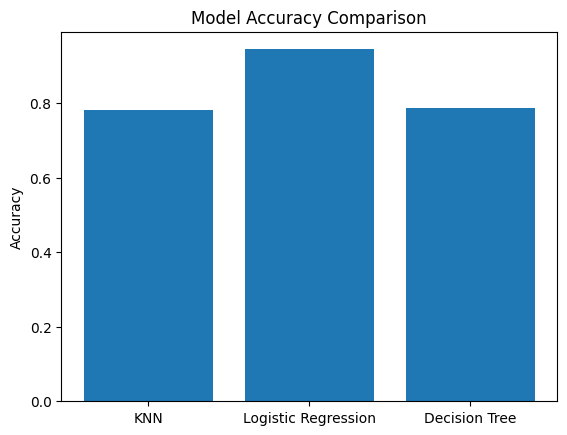

In [ ]:
models = ["KNN", "Logistic Regression", "Decision Tree"]

accuracies = [
    accuracy_score(y_tes, y_pred),
    lr_accuracy,
    dt_accuracy
]

plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

**Interpretation**

The Titanic dataset was used to predict passenger survival using machine learning models.
Three algorithms were applied: KNN, Logistic Regression, and Decision Tree.

After training and testing the models, Logistic Regression achieved the highest accuracy,
followed by KNN and Decision Tree. The comparison shows that Logistic Regression performs
better for this dataset in predicting passenger survival.